In [1]:
import sys,os
from pathlib import Path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import fx_hedges.fxshort_gates


In [9]:
a=np.array([2,3,4,5,np.nan, 6])
b=np.array([1,1.1,1.21,1.331,1.4641,1.61051, 1.771561])
c=np.array([1,2,3,4,5,6,np.nan,8,9,])
a_s = pd.Series(a)
b_s=pd.Series(b)
c_s=pd.Series(c)

b_s_drop=b_s.iloc[::-1]
# print(b_s_drop)

b_s_hill=pd.concat([b_s, b_s_drop]).dropna().reset_index(drop=True)
# print(b_s_hill)
b_s_hill_log=np.log(b_s_hill)
print(b_s_hill_log)

b_s_rets=np.log(b_s / b_s.shift(1)).dropna()
# print(b_s_rets)

b_s_drop_rets=np.log(b_s_drop / b_s_drop.shift(1)).dropna()
# print(b_s_drop_rets)



b_s_hill_rets=np.log(b_s_hill / b_s_hill.shift(1)).dropna()
# print(b_s_hill_rets)
# print(b_slog)
# reverse teh series

# print(b_slog_reverse)

0     0.000000
1     0.095310
2     0.190620
3     0.285931
4     0.381241
5     0.476551
6     0.571861
7     0.571861
8     0.476551
9     0.381241
10    0.285931
11    0.190620
12    0.095310
13    0.000000
dtype: float64


In [ ]:
slope1=fx_hedges.fxshort_gates._rolling_ols_slope(b_s_rets,2)
slope2=fx_hedges.fxshort_gates._rolling_ols_slope(b_s_drop_rets,2)
slope3=fx_hedges.fxshort_gates._rolling_ols_slope(b_s_hill_log,2)

difs=b_s_hill_log.diff()
print(difs)
roll_difs=difs.rolling(window=5, min_periods=5).mean()
print(roll_difs)
# print(slope1)
# print(slope2)
# print(difs)





plt.plot(difs, label='diffs', color='green')
plt.plot(roll_difs, label='roll_difs')




In [20]:
p = pd.Series(100 * (1.01 ** np.arange(30)))  # ~1% per bar
print(p)
log_p = np.log(p)
slope = fx_hedges.fxshort_gates._rolling_ols_slope(log_p, window=10)
print(slope.dropna().iloc[-1])  # ≈ np.log(1.01) ~ 0.00995

0     100.000000
1     101.000000
2     102.010000
3     103.030100
4     104.060401
5     105.101005
6     106.152015
7     107.213535
8     108.285671
9     109.368527
10    110.462213
11    111.566835
12    112.682503
13    113.809328
14    114.947421
15    116.096896
16    117.257864
17    118.430443
18    119.614748
19    120.810895
20    122.019004
21    123.239194
22    124.471586
23    125.716302
24    126.973465
25    128.243200
26    129.525631
27    130.820888
28    132.129097
29    133.450388
dtype: float64
0.009950330853168102


In [ ]:
log_s = np.log(s)
fit = fx_hedges.fxshort_gates.rolling_ols_fit(log_s, 20)
last_t = fit.index[-1]
b1 = fit.loc[last_t, 'slope']
b0 = fit.loc[last_t, 'intercept']

# Build fitted line for last window
x = np.arange(len(s[-20:]))
y_hat = b0 + b1 * x

plt.figure(figsize=(10,5))
plt.plot(log_s.index, log_s, label='log(price)', color='steelblue')
plt.plot(log_s.index[-20:], y_hat, label='last 20d OLS fit', color='crimson')
plt.legend()
plt.show()


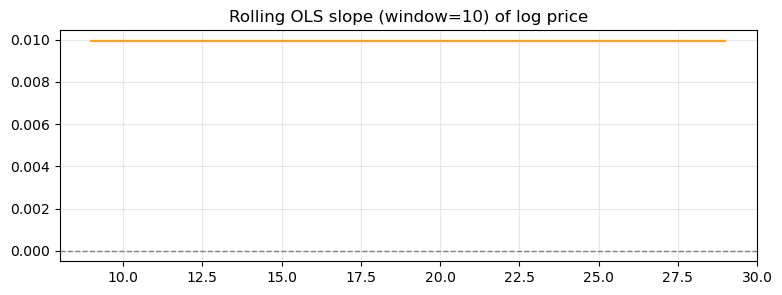

In [21]:
fig, ax = plt.subplots(figsize=(9, 3))
slope.plot(ax=ax, color='orange', lw=1.5)
ax.axhline(0, color='gray', lw=1, ls='--')
ax.set_title('Rolling OLS slope (window=10) of log price')
ax.grid(True, alpha=0.3)
plt.show()

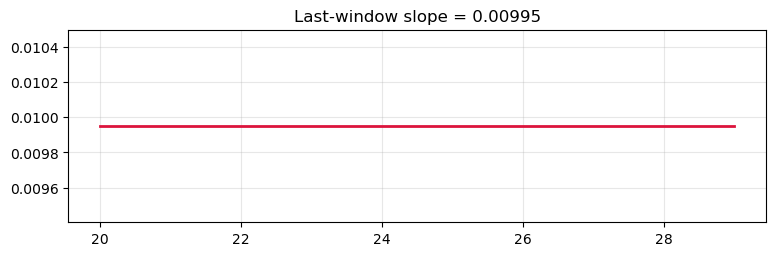

In [22]:
w = 10
idx_last = log_p.tail(w).index
last_slope = slope.dropna().iloc[-1]
plt.figure(figsize=(9, 2.5))
plt.plot(idx_last, np.full(w, last_slope), color='crimson', lw=2)
plt.title(f'Last-window slope = {last_slope:.5f}')
plt.grid(True, alpha=0.3)
plt.show()

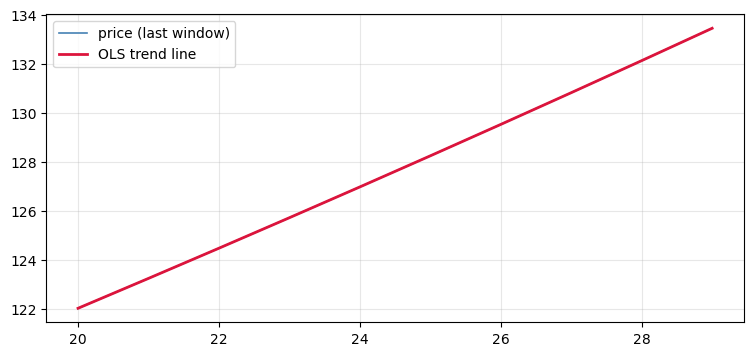

In [23]:
w = 10
x = np.arange(w)
y = log_p.tail(w).values
t = log_p.tail(w).index

b = slope.dropna().iloc[-1]                  # slope
a = y.mean() - b * x.mean()                  # intercept
y_hat = a + b * x
p_hat = np.exp(y_hat)                        # back to price space

fig, ax = plt.subplots(figsize=(9, 4))
p.tail(w).plot(ax=ax, color='steelblue', lw=1.2, label='price (last window)')
ax.plot(t, p_hat, color='crimson', lw=2, label='OLS trend line')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()